In [3]:
import h5py
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import pandas as pd
from tqdm import tqdm
import astropy.units as u

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'font.size': 20,         #tamaño de fuente general
    'axes.titlesize': 20,    #tamaño de fuente para títulos de ejes
    'axes.labelsize': 20,    #tamaño de fuente para etiquetas de ejes
    'xtick.labelsize': 20,   #tamaño de fuente para etiquetas del eje x
    'ytick.labelsize': 20,   #tamaño de fuente para etiquetas del eje y
    'legend.fontsize': 20,   #tamaño de fuente para la leyenda
    'figure.titlesize': 20   #tamaño de fuente para el título de la figura
})

plt.style.use(['science', 'grid'])

In [4]:
df_constSF_colevol = pd.read_csv('constSF_colevol.csv', delimiter = ',', header = 0, names = ['NUV-r', 'g-r', 't[Myr]'])
NUV_r = np.asarray(df_constSF_colevol['NUV-r'])
g_r = np.asarray(df_constSF_colevol['g-r'])
t_Myr = np.asarray(df_constSF_colevol['t[Myr]'])
print(df_constSF_colevol)

           NUV-r       g-r  t[Myr]
0      -1.566200 -0.489600       0
1      -1.566200 -0.489600       0
2      -1.566200 -0.489600       0
3      -1.566200 -0.489600       0
4      -1.566200 -0.489600       0
...          ...       ...     ...
139995  1.392522  0.348252   13999
139996  1.392523  0.348252   13999
139997  1.392525  0.348253   13999
139998  1.392527  0.348253   13999
139999  1.392529  0.348254   14000

[140000 rows x 3 columns]


In [5]:
#(Bruzual & Charlot+2016)
df_singleburst = pd.read_csv('singleburst.csv', delimiter = ',', header = 0, names = ['t[yr]', 'M_FUV', 'M_NUV', 'M_u', 'M_g', 'M_r'])
t_yr = np.asarray(df_singleburst['t[yr]'])
M_FUV = np.asarray(df_singleburst['M_FUV'])
M_NUV = np.asarray(df_singleburst['M_NUV'])
M_u = np.asarray(df_singleburst['M_u'])
M_g = np.asarray(df_singleburst['M_g'])
M_r = np.asarray(df_singleburst['M_r'])
#Luminosity
L_g = 10**(-M_g/2.5)
L_r = 10**(-M_r/2.5)
print(df_singleburst)

               t[yr]      M_FUV      M_NUV        M_u       M_g       M_r
0       0.000000e+00  -0.855100  -0.459600   0.218100  0.617000  1.106600
1       1.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
2       2.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
3       3.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
4       4.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
...              ...        ...        ...        ...       ...       ...
199996  1.999960e+10  13.824986  13.536676  10.019875  8.071281  7.197982
199997  1.999970e+10  13.824989  13.536682  10.019881  8.071286  7.197986
199998  1.999980e+10  13.824992  13.536688  10.019887  8.071290  7.197991
199999  1.999990e+10  13.824996  13.536693  10.019893  8.071295  7.197995
200000  2.000000e+10  13.824999  13.536699  10.019899  8.071300  7.197999

[200001 rows x 6 columns]


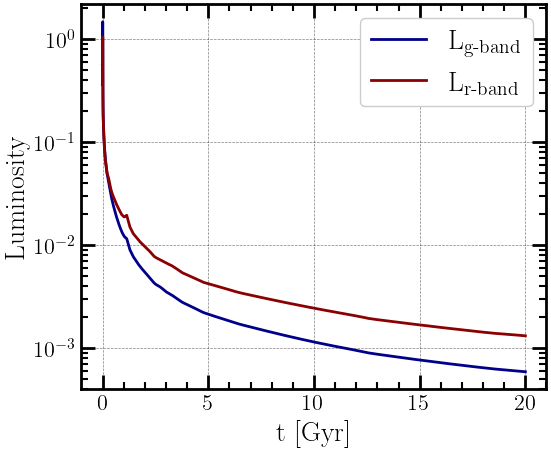

In [6]:
#plot de la luminosidad
fig = plt.figure(figsize = (6,5))
gs = fig.add_gridspec()
ax = gs.subplots()

for i in range(0, 2):
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)
    ax.tick_params(axis='both', which='minor', length=5, width=1.5)
    ax.minorticks_on()
    
ax.plot(t_yr/10**9, L_g, color = 'darkblue', lw = 2, label = r'L$_{\text{g-band}}$')
ax.plot(t_yr/10**9, L_r, color = 'darkred', lw = 2, label = r'L$_{\text{r-band}}$')
ax.set_xlabel('t [Gyr]')
ax.set_ylabel(r'Luminosity')
ax.set_yscale('log')
ax.legend(fontsize= 20)
plt.show()

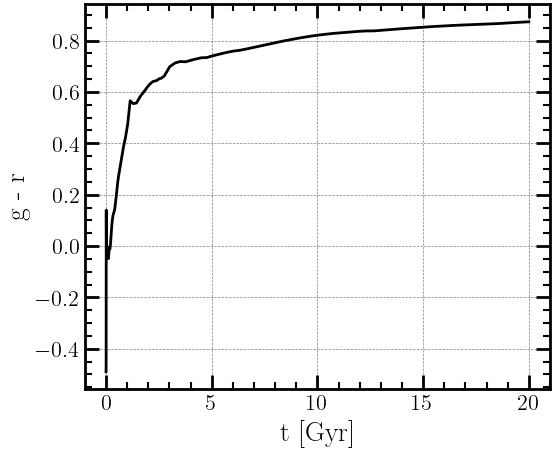

In [7]:
#plot del color
fig = plt.figure(figsize = (6,5))
gs = fig.add_gridspec()
ax = gs.subplots()

for i in range(0, 2):
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)
    ax.tick_params(axis='both', which='minor', length=5, width=1.5)
    ax.minorticks_on()
    
ax.plot(t_yr/10**9, (M_g-M_r), color = 'black', lw = 2)
ax.set_xlabel('t [Gyr]')
ax.set_ylabel('g - r')
plt.show()

In [8]:
#pregunta 2
t_end = 14*10**3 #en Myr (cambiar, según la edad que se le quiera dar a la galaxia)
dt = 1 #Myr
n_steps = int(t_end/dt) 
jump = int(dt/0.1) #jump en las columnas del archivo singleburst, para que concuerde con el dt !!

In [12]:
sfr = np.array([3]*n_steps) *(dt*10**6)
print('Array de sfr: ', sfr)
print('Largo del array de sfr: ', len(sfr))
print('Número de pasos, según el dt: ', n_steps)
#sfr = np.zeros(n_steps) 
#sfr[0] = 3 * (dt*10**6) #ejemplo para un single burst al inicio de la galaxia (duración según dt)
#sfr[np.asarray([0,1,2])] #ejemplo para 3 bursts (duración según el dt)

Array de sfr:  [3000000 3000000 3000000 ... 3000000 3000000 3000000]
Largo del array de sfr:  14000
Número de pasos, según el dt:  14000


In [10]:
m_g_arr = []
m_r_arr = []

t_arr = []

for i in tqdm(range(0, n_steps), 'Procesando: '):
    t_now = i*dt
    t_arr.append(t_now)
    k = i + 1
    l_g, l_r = 0, 0
    for j in range(0, i):
        k = k - 1
        l_g = l_g + sfr[j]*dt*L_g[k*jump]
        l_r = l_r + sfr[j]*dt*L_r[k*jump]
    m_g = -2.5 * np.log10(l_g)
    m_r = -2.5 * np.log10(l_r)
    m_g_arr.append(m_g)
    m_r_arr.append(m_r)

print(f'm_g = {m_r}')
print('----------------------------')
print(f'm_g - m_r = {m_g-m_r}')
print('----------------------------')
print(f't_now = {t_now} [Myr]')

Procesando:   0%|                                     | 0/14000 [00:00<?, ?it/s]/tmp/ipykernel_21748/204770685.py:15: RuntimeWarning: divide by zero encountered in log10
  m_g = -2.5 * np.log10(l_g)
/tmp/ipykernel_21748/204770685.py:16: RuntimeWarning: divide by zero encountered in log10
  m_r = -2.5 * np.log10(l_r)
Procesando: 100%|█████████████████████████| 14000/14000 [03:49<00:00, 61.05it/s]

m_g = -21.248598551118402
----------------------------
m_g - m_r = 0.35006391666965087
----------------------------
t_now = 13999 [Myr]


In [167]:
m_g_arr = np.asarray(m_g_arr)
m_r_arr = np.asarray(m_r_arr)
g_r_arr = m_g_arr-m_r_arr
t_arr = np.asarray(t_arr)

/tmp/ipykernel_29884/3585842212.py:3: RuntimeWarning: invalid value encountered in subtract
  g_r_arr = m_g_arr-m_r_arr


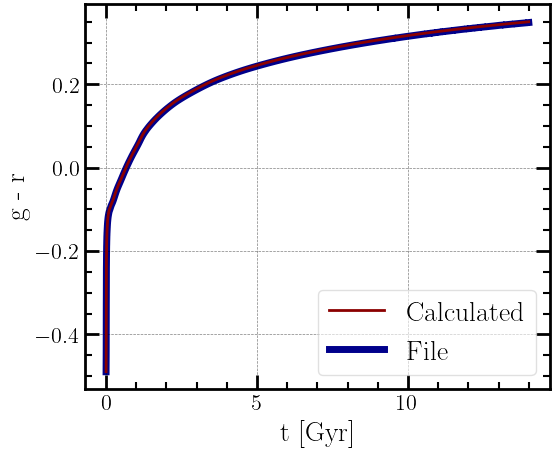

In [168]:
#plot del color
fig = plt.figure(figsize = (6,5))
gs = fig.add_gridspec()
ax = gs.subplots()

for i in range(0, 2):
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)
    ax.tick_params(axis='both', which='minor', length=5, width=1.5)
    ax.minorticks_on()
    
ax.plot(t_arr/10**3, g_r_arr, color = 'darkred', label = 'Calculated', lw = 2, zorder = 1)
ax.plot(t_Myr/10**3, g_r, color = 'darkblue', label = 'File', lw = 5, zorder = 0)


ax.set_ylabel('g - r')
ax.set_xlabel('t [Gyr]')

ax.legend(framealpha = 0.6)

plt.show()